In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-01-31' #'2024-10-22'
sample =  'all' # 'randomsample500'

### Load data

In [3]:
metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-11-26.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [4]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Variable']]

In [5]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [6]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
full_table

49867
49867
56319
49867


,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,Type of Adopter,Granularity Numerical,Granularity,Average lifetime,Technology Lifetime,Strict replacement,Broad replacement,Feedstock,Category Type,Patent Category Name
0,exponential,curve_fit,True,0.487690,0.481543,7.392699e+03,7.694435e+03,1.051031,100.391781,0.010812,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
1,linear,curve_fit,True,0.406591,0.401862,8.497110e+03,8.730111e+03,1.528609,-1800.686448,1.014233,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
2,logistic,curve_fit,True,0.706834,0.703316,4.230428e+03,4.403095e+03,0.760129,289.208416,0.201153,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
3,gompertz,curve_fit,True,0.699004,0.695392,4.343411e+03,4.520689e+03,0.784392,287.769584,0.171707,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
4,softplus,curve_fit,True,0.513636,0.507799,7.018306e+03,7.304761e+03,0.880879,2.500417,0.090887,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56314,softplus,curve_fit,True,0.939718,0.909578,1.087347e+09,1.149038e+09,0.243888,39833.928174,1.002135,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56315,logistic-linear-cont,curve_fit,True,0.943906,0.915858,1.011818e+09,1.069223e+09,0.217256,260854.368598,0.613273,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56316,bass,curve_fit,True,0.924427,0.863968,1.533574e+09,1.636693e+09,0.324492,0.000001,0.008213,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56317,bertalanffy,curve_fit,True,0.954790,0.932185,8.154841e+08,8.617504e+08,0.314927,361745.557682,0.342127,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions


In [7]:
# correct internally inconsistent labels
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [8]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)

In [9]:
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
full_table['metric_grouped'] = full_table['Metric'].map(group_metrics)

## Plot distribution of growth parameters

/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(-7.0, 7.0)

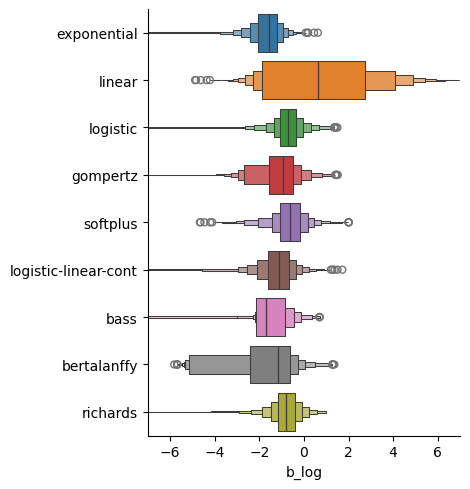

In [10]:
# boxen plot

full_table['b_log'] = np.log10(full_table['b'])
full_tablef = full_table[full_table['r_squared_masked'].notna()]

sns.catplot(y='functional_form', x='b_log', hue='functional_form',
            data=full_tablef, kind='boxen', legend=False)
plt.ylabel('')
plt.xlim([-7, 7])

(-7.0, 7.0)

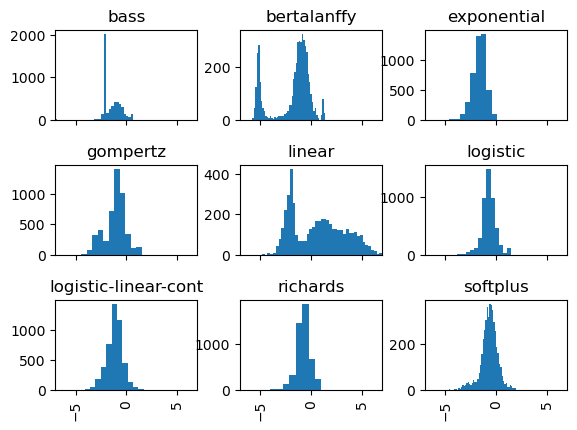

In [11]:
# histogram

full_tablef.hist(column='b_log', by='functional_form', bins=50, sharex=True)
plt.xlim([-7, 7])

# Correlation of growth parameters

In [15]:
ff_order = ['linear', 'logistic', 'gompertz', 'bertalanffy', 'richards', 'bass', 'exponential', 'logistic-linear-cont', 'softplus']

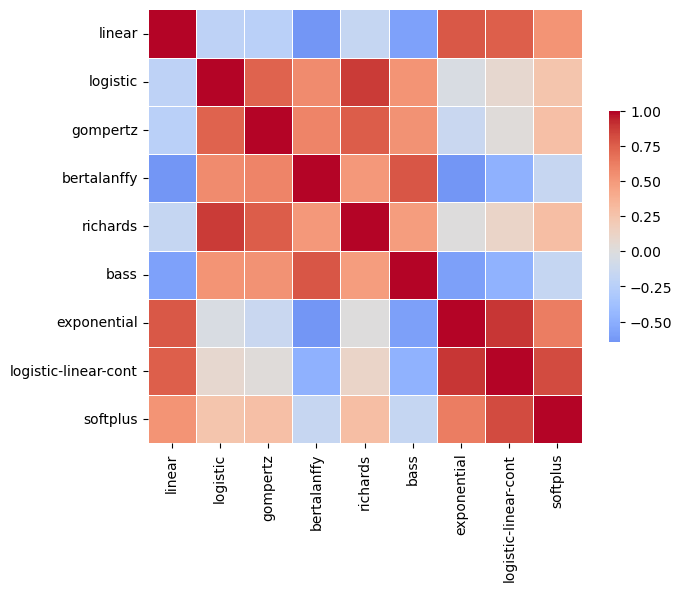

In [31]:
# Rank correlation of growth parameters

gr_vals = full_table.pivot(index='technology', columns='functional_form', values='b')
rank_corr_b = gr_vals[ff_order].corr(method='spearman')

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(7, 6))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(rank_corr_b, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.ylabel('')
plt.xlabel('')

if save_fig:
    plt.savefig('figures/b_rank_correlation.png', **savefig_settings)

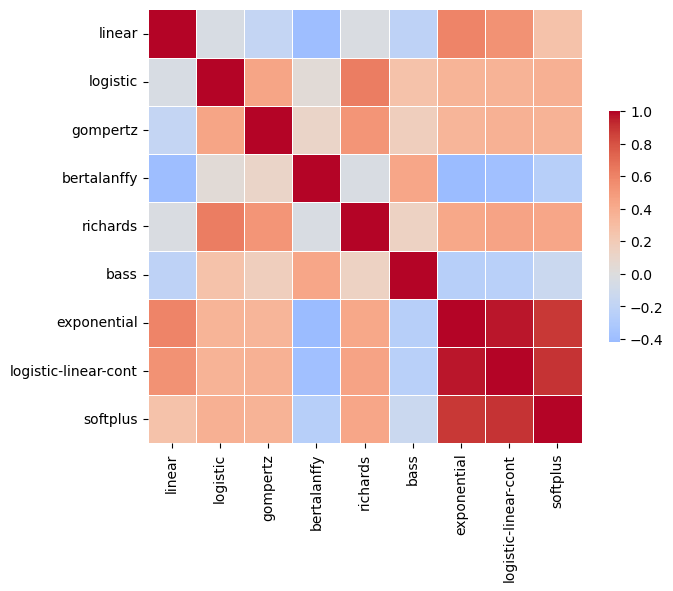

In [30]:
# Pearson correlation of logged growth parameters

log_gr_vals = full_table.pivot(index='technology', columns='functional_form', values='b_log')
corr_log_b = log_gr_vals[ff_order].corr(method='pearson')

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(7, 6))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_log_b, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.ylabel('')
plt.xlabel('')

if save_fig:
    plt.savefig('figures/b_rank_correlation.png', **savefig_settings)

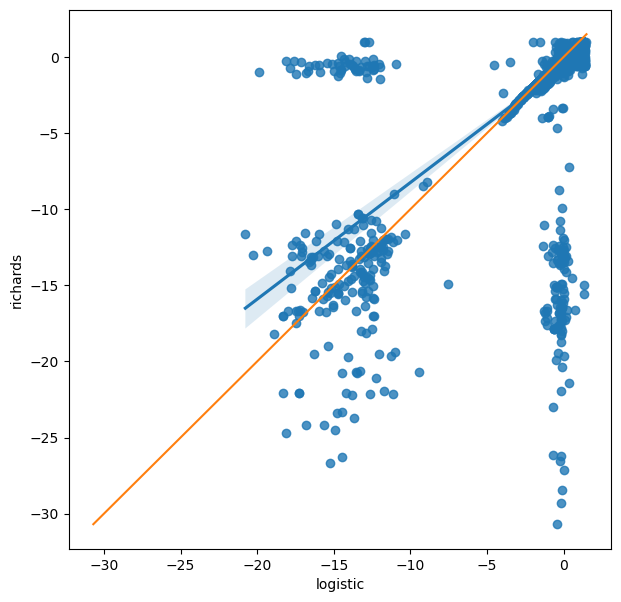

In [40]:
# plot one relationsship
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
x_var = 'logistic'
y_var = 'richards'
sns.regplot(data=log_gr_vals, x=x_var, y=y_var)
v_max = log_gr_vals[[x_var, y_var]].max().max()
v_min = log_gr_vals[[x_var, y_var]].min().min()
plt.plot([v_min, v_max], [v_min, v_max])

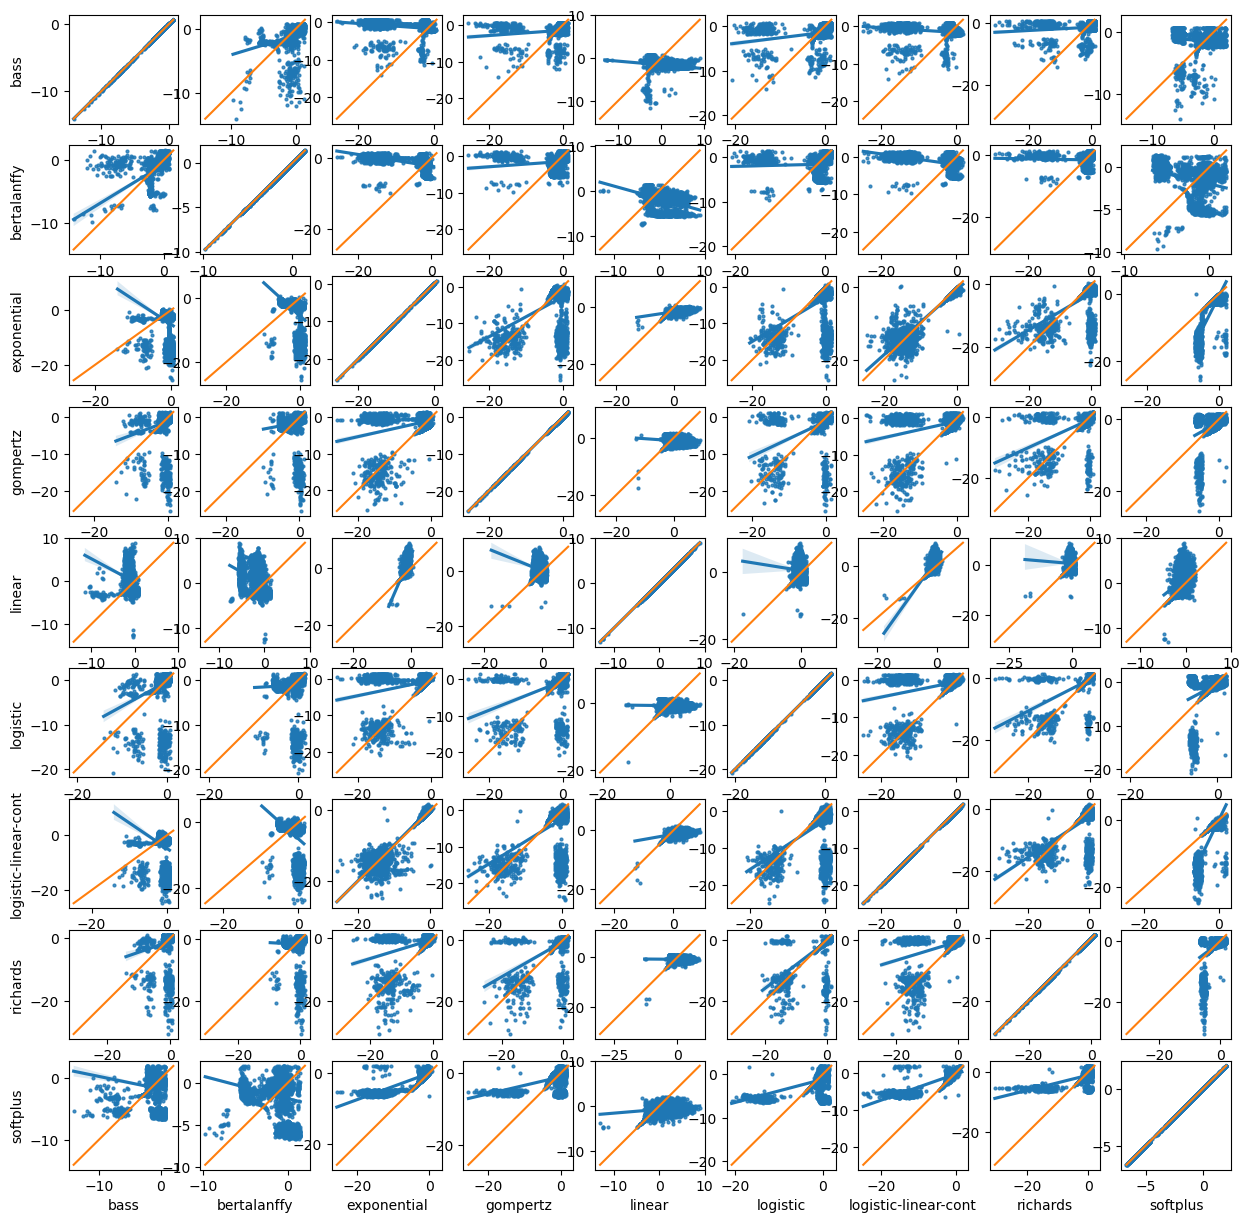

In [42]:
fig, axs = plt.subplots(len(log_gr_vals.columns), len(log_gr_vals.columns), figsize=(15, 15))

for i in range(len(log_gr_vals.columns)):
    y_var = log_gr_vals.columns[i]
    for j in range(len(log_gr_vals.columns)):
        x_var = log_gr_vals.columns[j]

        sns.regplot(data=log_gr_vals, x=x_var, y=y_var, ax=axs[i][j], scatter_kws={'s': 4})
        v_max = log_gr_vals[[x_var, y_var]].max().max()
        v_min = log_gr_vals[[x_var, y_var]].min().min()
        axs[i][j].plot([v_min, v_max], [v_min, v_max])
        if j > 0:
            axs[i][j].set_ylabel('')
        if (i + 1) < len(log_gr_vals.columns):
            axs[i][j].set_xlabel('')

if save_fig:
    fig.savefig('figures/linear_regressions_log_growth_pars.png', **savefig_settings)

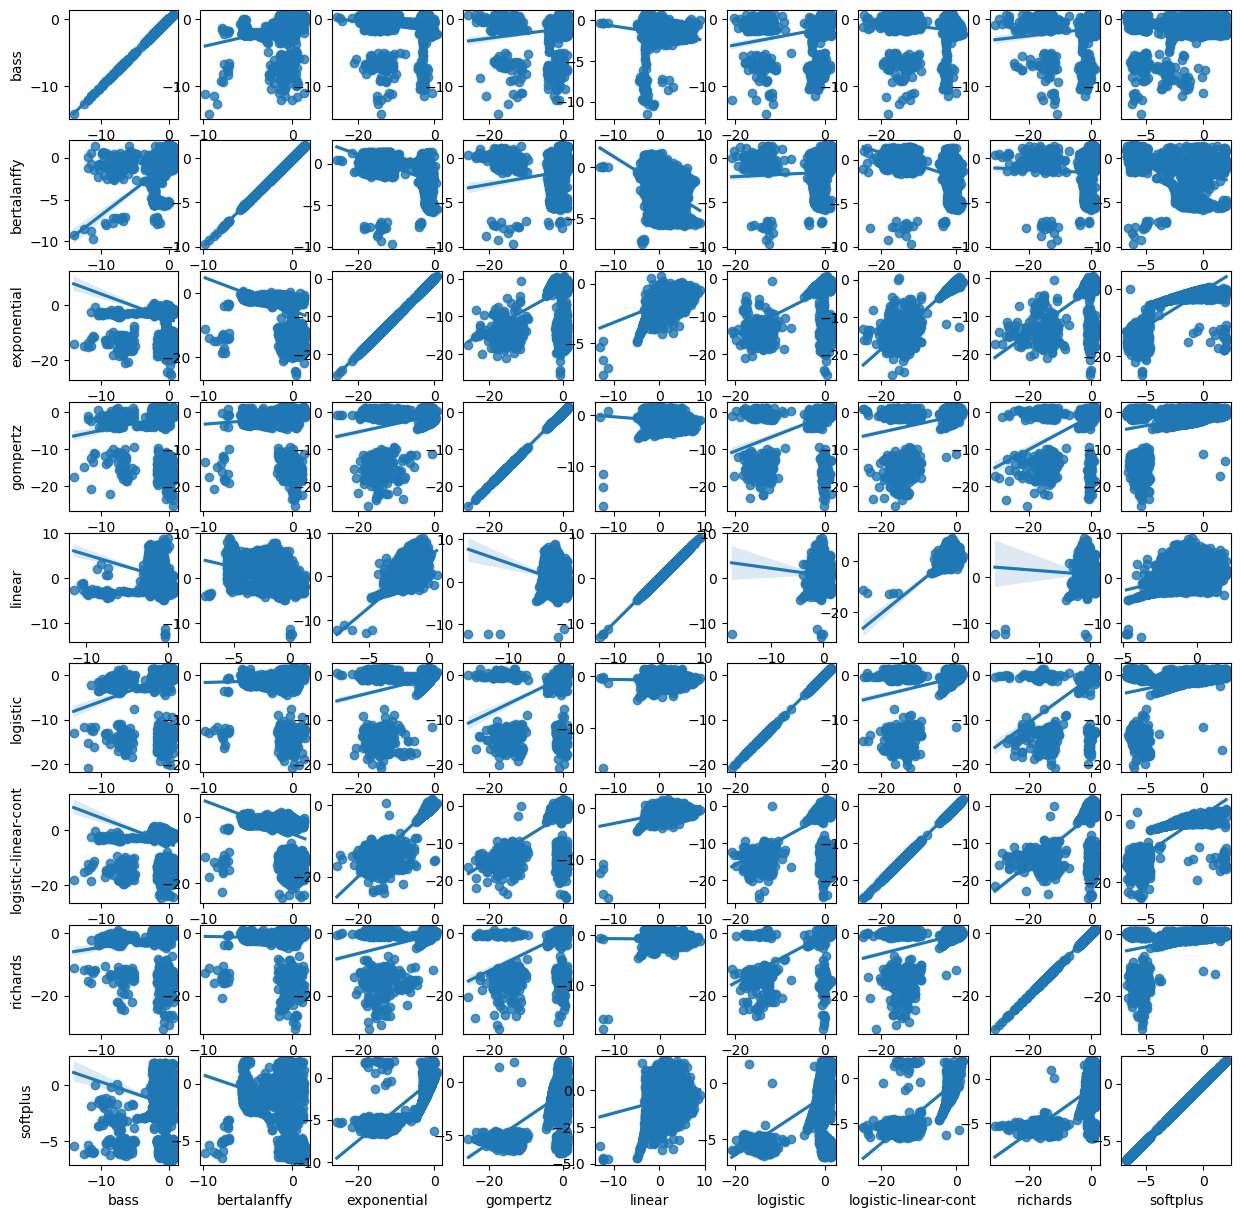

In [43]:
# with shared axis

fig, axs = plt.subplots(len(log_gr_vals.columns), len(log_gr_vals.columns), figsize=(15, 15))

for i in range(len(log_gr_vals.columns)):
    y_var = log_gr_vals.columns[i]
    for j in range(len(log_gr_vals.columns)):
        x_var = log_gr_vals.columns[j]

        sns.regplot(data=log_gr_vals, x=x_var, y=y_var, ax=axs[i][j]) 
        if j > 0:
            axs[i][j].set_ylabel('')
        if (i + 1) < len(log_gr_vals.columns):
            axs[i][j].set_xlabel('')

if save_fig:
    fig.savefig('figures/linear_regressions_log_growth_pars_shared_axis.png', **savefig_settings)

In [35]:
# extract linear regression coefficients

import statsmodels.api as sm

reg_coef = pd.DataFrame(index=gr_vals.columns, columns=gr_vals.columns)
pval = pd.DataFrame(index=gr_vals.columns, columns=gr_vals.columns)


for i in range(len(gr_vals.columns)):
    y_var = gr_vals.columns[i]
    for j in range(len(gr_vals.columns)):
        x_var = gr_vals.columns[j]

        if i == j:
            gr_filtered = gr_vals[[x_var]].dropna()
    
            x = gr_filtered[x_var]
            y = gr_filtered[x_var]  
        else:
            gr_filtered = gr_vals[[x_var, y_var]].dropna()
    
            x = gr_filtered[x_var]
            y = gr_filtered[y_var]        
    
        x = sm.add_constant(x)
        model = sm.OLS(y,x)
        results = model.fit()
        # print(results.params)
        reg_coef.loc[x_var, y_var] = results.params.iloc[1]
        pval.loc[x_var, y_var] = results.f_pvalue

reg_coef

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0,2.344593,-0.018071,1.23308,104115.889898,1.798437,-0.100782,0.845268,0.178402
bertalanffy,0.203303,1.0,-0.004186,0.336267,-36634.266369,0.486441,-0.022881,0.213429,0.020127
exponential,-0.996121,-2.661141,1.0,-0.242718,4629814.681517,-0.089603,2.56915,0.528243,7.967196
gompertz,0.134369,0.422577,-0.00048,1.0,-33728.49216,0.745644,0.025274,0.456974,0.179557
linear,0.0,-0.0,0.0,-0.0,1.0,-0.0,0.0,-0.0,-0.0
logistic,0.145009,0.452312,-0.000131,0.551719,-24123.044817,1.0,0.02472,0.343928,0.256029
logistic-linear-cont,-0.051998,-0.136145,0.024048,0.119666,21085.46152,0.158183,1.0,0.102639,3.243125
richards,0.296508,0.860201,0.002257,1.435535,-39503.651628,1.466748,0.063595,1.0,0.465112
softplus,0.002973,0.003869,0.002409,0.027465,-6452.475593,0.052926,0.104769,0.023687,1.0


In [36]:
reg_coef_exp = reg_coef.map(lambda x: '{0:.2f}'.format(x)).mask(pval > 0.05).fillna('')
if save_fig:
    reg_coef_exp.to_csv('results/growth_paras_regression_coefficients.csv')
reg_coef_exp

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.00,2.34,-0.02,1.23,,1.80,-0.10,0.85,
bertalanffy,0.20,1.00,-0.00,0.34,,0.49,-0.02,0.21,
exponential,-1.00,-2.66,1.00,,4629814.68,,2.57,0.53,7.97
gompertz,0.13,0.42,,1.00,,0.75,0.03,0.46,0.18
linear,,,0.00,,1.00,,,,
logistic,0.15,0.45,,0.55,,1.00,0.02,0.34,0.26
logistic-linear-cont,-0.05,-0.14,0.02,0.12,,0.16,1.00,0.10,3.24
richards,0.30,0.86,0.00,1.44,,1.47,0.06,1.00,0.47
softplus,,,0.00,0.03,,0.05,0.10,0.02,1.00


In [44]:
# linear regression coefficients only for parameters with high goodness of fit

r2_vals = full_table.pivot(index='technology', columns='functional_form', values='r_squared')
gr_valsf = gr_vals.mask(r2_vals > 0.9)

import statsmodels.api as sm

reg_coef = pd.DataFrame(index=gr_valsf.columns, columns=gr_valsf.columns)
pval = pd.DataFrame(index=gr_valsf.columns, columns=gr_valsf.columns)


for i in range(len(gr_vals.columns)):
    y_var = gr_valsf.columns[i]
    for j in range(len(gr_valsf.columns)):
        x_var = gr_valsf.columns[j]

        if i == j:
            gr_filtered = gr_valsf[[x_var]].dropna()
    
            x = gr_filtered[x_var]
            y = gr_filtered[x_var]  
        else:
            gr_filtered = gr_valsf[[x_var, y_var]].dropna()
    
            x = gr_filtered[x_var]
            y = gr_filtered[y_var]        
    
        x = sm.add_constant(x)
        model = sm.OLS(y,x)
        results = model.fit()
        # print(results.params)
        reg_coef.loc[x_var, y_var] = results.params.iloc[1]
        pval.loc[x_var, y_var] = results.f_pvalue

reg_coef

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.0,2.220394,-0.008694,0.86087,120226.250523,1.510112,-0.063777,0.667748,0.319481
bertalanffy,0.185339,1.0,-0.001493,0.224038,-9626.217929,0.390729,-0.011846,0.160816,0.047871
exponential,-2.493212,-5.738973,1.0,1.276911,163706.110246,-0.845128,4.460298,0.76447,23.690606
gompertz,0.114592,0.358086,0.00046,1.0,-636.536681,0.667514,0.011443,0.424363,0.109846
linear,0.0,-0.0,0.0,-0.0,1.0,-0.000001,0.0,-0.0,0.0
logistic,0.127458,0.397059,-0.000195,0.423473,-1270.181202,1.0,0.007472,0.281334,0.193064
logistic-linear-cont,-0.070871,-0.201615,0.015184,0.421921,4325.287,0.43005,1.0,0.248092,3.268588
richards,0.28326,0.821452,0.000862,1.353153,-1552.400057,1.414018,0.021429,1.0,0.333201
softplus,0.006447,0.012541,0.001477,0.020982,48.725346,0.057776,0.059841,0.019848,1.0


In [45]:
reg_coef_exp = reg_coef.map(lambda x: '{0:.2f}'.format(x)).mask(pval > 0.05).fillna('')
if save_fig:
    reg_coef_exp.to_csv('results/growth_paras_high_r2_regression_coefficients.csv')
reg_coef_exp

functional_form,bass,bertalanffy,exponential,gompertz,linear,logistic,logistic-linear-cont,richards,softplus
functional_form,,,,,,,,,
bass,1.00,2.22,-0.01,0.86,,1.51,-0.06,0.67,0.32
bertalanffy,0.19,1.00,-0.00,0.22,,0.39,-0.01,0.16,
exponential,-2.49,-5.74,1.00,,163706.11,,4.46,,23.69
gompertz,0.11,0.36,,1.00,,0.67,0.01,0.42,0.11
linear,,,0.00,,1.00,,,,
logistic,0.13,0.40,,0.42,,1.00,0.01,0.28,0.19
logistic-linear-cont,-0.07,-0.20,0.02,0.42,,0.43,1.00,0.25,3.27
richards,0.28,0.82,,1.35,,1.41,0.02,1.00,0.33
softplus,0.01,,0.00,0.02,,0.06,0.06,0.02,1.00
